# VectorDrive-Route: Visualization Notebook

This notebook runs the pipeline on validation samples and shows intermediate outputs for debugging and analysis.

We visualize eight stages: stitching, backbone features, depth lifting, BEV pooling, temporal fusion, trajectory scoring, trajectory regression, and auxiliary safety outputs.

See the architecture diagram in `README.md` for a compact overview.


## Environment & Imports

Set up Python path, import libraries, and initialize the model and dataset. Code cells below run unchanged.


In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# Ensure project root is in path
sys.path.append(os.getcwd())

from datasets.nuscenes_dataset import NuscenesDataset
from models.model import VectorDriveRouteModel

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")



Running on device: cpu


## Load Data and Checkpoint

Load the `nuScenes-mini` validation split and a local checkpoint. If the checkpoint contains additional fields, the loader tolerates that.


In [2]:
# Load dataset
dataset = NuscenesDataset(
    version='v1.0-mini', 
    dataroot='data/nuscenes', 
    split='val', 
    downscale_factor=2
)
print(f"Loaded validation split with {len(dataset)} samples.")

# Load pre-trained checkpoint
checkpoint_path = "checkpoints/best_model.pth"
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    anchors = checkpoint['anchors']
    model = VectorDriveRouteModel(anchors=anchors).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}. Please run train or verify evaluation first.")

model.eval()
print("Model loaded and set to evaluation mode.")



Loaded validation split with 130 samples.
Loading checkpoint from checkpoints/best_model.pth...
Model loaded and set to evaluation mode.


## Fetch Consecutive Samples

Get two consecutive validation samples to demonstrate temporal fusion and warping. We use `sample_0` (t-1) and `sample_1` (t).


In [3]:
# Get consecutive samples (same scene validation split)
sample_0 = dataset[0]
sample_1 = dataset[1]

# Package sample_1 into batch dimension for model input
images_1 = sample_1['images'].unsqueeze(0).to(device)
intrinsics_1 = sample_1['intrinsics'].unsqueeze(0).to(device)
extrinsics_1 = sample_1['extrinsics'].unsqueeze(0).to(device)
ego_state_1 = sample_1['ego_state'].unsqueeze(0).to(device)

print("Fetched consecutive samples from NuScenes dataset.")
print(f"Ego vehicle current velocity (vx): {sample_1['ego_state'][0].item():.2f} m/s")
print(f"Ego vehicle current yaw rate: {sample_1['ego_state'][1].item():.2f} rad/s")



Fetched consecutive samples from NuScenes dataset.
Ego vehicle current velocity (vx): 0.00 m/s
Ego vehicle current yaw rate: 0.00 rad/s


---
## Stage 1: Cylindrical Stitching

Stitch the three front cameras into a single cylindrical panorama and compute validity/seam masks for sampling.

Visual checks: panorama, validity mask, and seam mask.


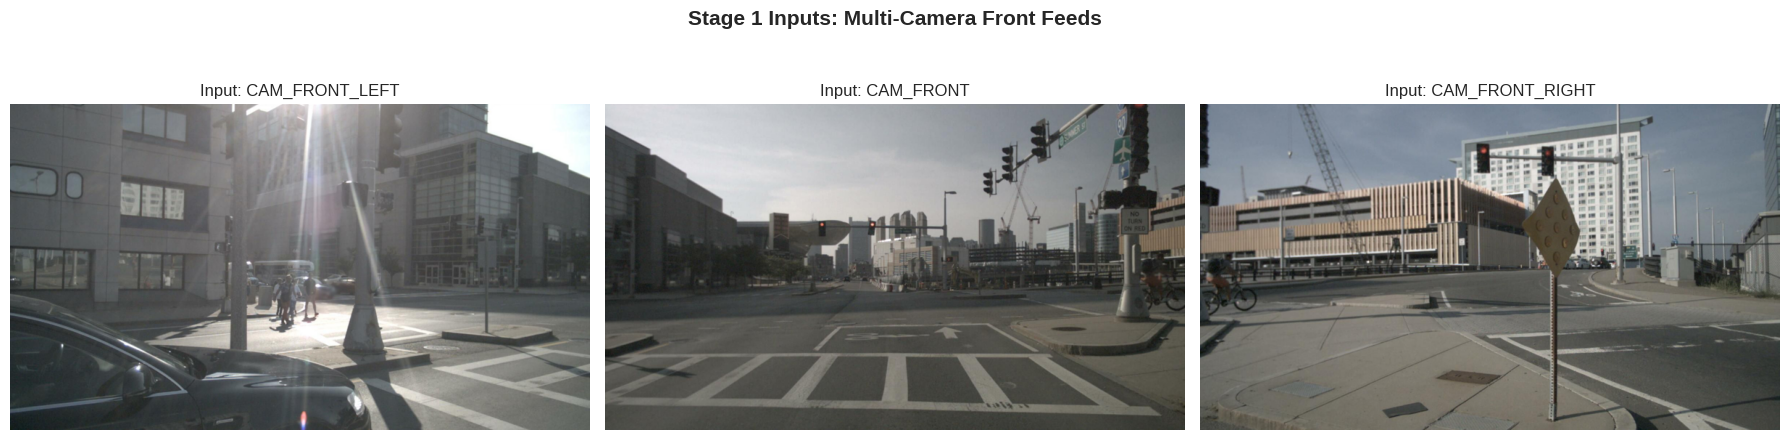

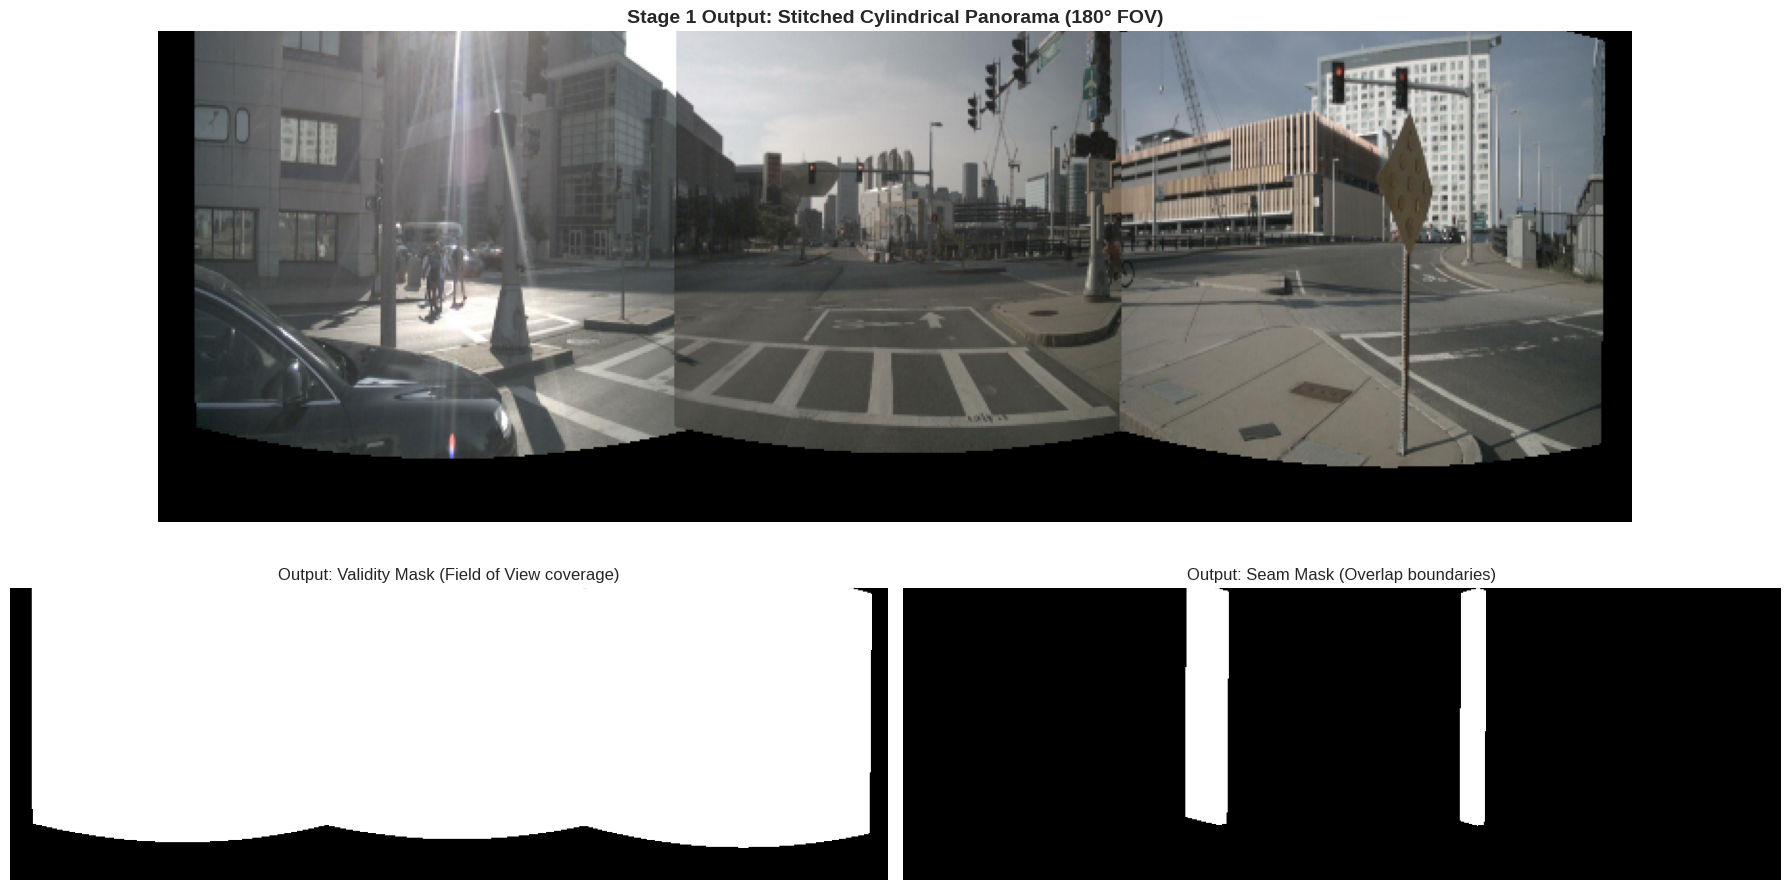

In [4]:
# Run cylindrical projection
with torch.no_grad():
    images_cyl_1, camera_mask_1, seam_mask_1, validity_mask_1 = model.projection(images_1, intrinsics_1, extrinsics_1)

# Visualize inputs: original 3 camera feeds
plt.figure(figsize=(18, 5))
cams = ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT']
for idx in range(3):
    plt.subplot(1, 3, idx + 1)
    img_np = sample_1['images'][idx].permute(1, 2, 0).numpy()
    plt.imshow(img_np)
    plt.title(f"Input: {cams[idx]}", fontsize=12)
    plt.axis('off')
plt.suptitle("Stage 1 Inputs: Multi-Camera Front Feeds", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize output: stitched cylindrical panorama and masks
plt.figure(figsize=(18, 10))
plt.subplot(2, 1, 1)
plt.imshow(images_cyl_1[0].permute(1, 2, 0).cpu().numpy())
plt.title("Stage 1 Output: Stitched Cylindrical Panorama (180° FOV)", fontsize=14, fontweight='bold')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(validity_mask_1[0, 0].cpu().numpy(), cmap='gray')
plt.title("Output: Validity Mask (Field of View coverage)", fontsize=12)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(seam_mask_1[0, 0].cpu().numpy(), cmap='gray')
plt.title("Output: Seam Mask (Overlap boundaries)", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()



---
## Stage 2: Backbone Features

Run the ResNet-18 backbone on the stitched panorama to get dense feature maps used by later stages.


Stitched Cylindrical Input Shape: torch.Size([1, 3, 256, 768])
Perspective Features Output Shape: torch.Size([1, 256, 32, 96])


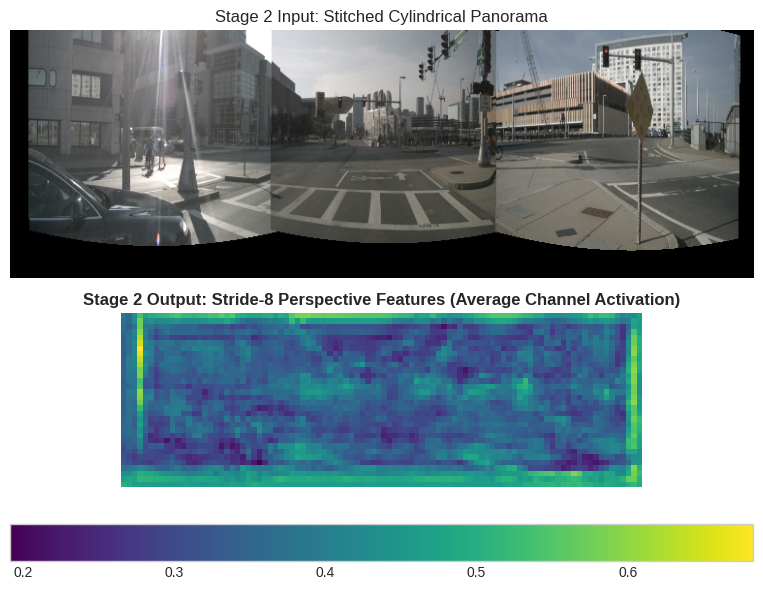

In [5]:
# Run backbone feature extraction
with torch.no_grad():
    feat_1 = model.backbone(images_cyl_1)
print(f"Stitched Cylindrical Input Shape: {images_cyl_1.shape}")
print(f"Perspective Features Output Shape: {feat_1.shape}")

# Visualize feature activations (mean along channels)
feat_mean_1 = torch.mean(feat_1[0], dim=0).detach().cpu().numpy()

plt.figure(figsize=(18, 6))
plt.subplot(2, 1, 1)
plt.imshow(images_cyl_1[0].permute(1, 2, 0).cpu().numpy())
plt.title("Stage 2 Input: Stitched Cylindrical Panorama", fontsize=12)
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(feat_mean_1, cmap='viridis', aspect='equal')
plt.title("Stage 2 Output: Stride-8 Perspective Features (Average Channel Activation)", fontsize=12, fontweight='bold')
plt.colorbar(orientation='horizontal', pad=0.15)
plt.axis('off')
plt.tight_layout()
plt.show()



---
## Stage 3: Depth Lift (LSS)

Predict categorical depth and lift 2D features into a 3D frustum. Visualize the expected depth map over sparse LiDAR points.


Perspective Features Input Shape: torch.Size([1, 256, 32, 96])
Frustum Tensor Output Shape: torch.Size([1, 80, 40, 32, 96])
Depth Probabilities Output Shape: torch.Size([1, 40, 32, 96])


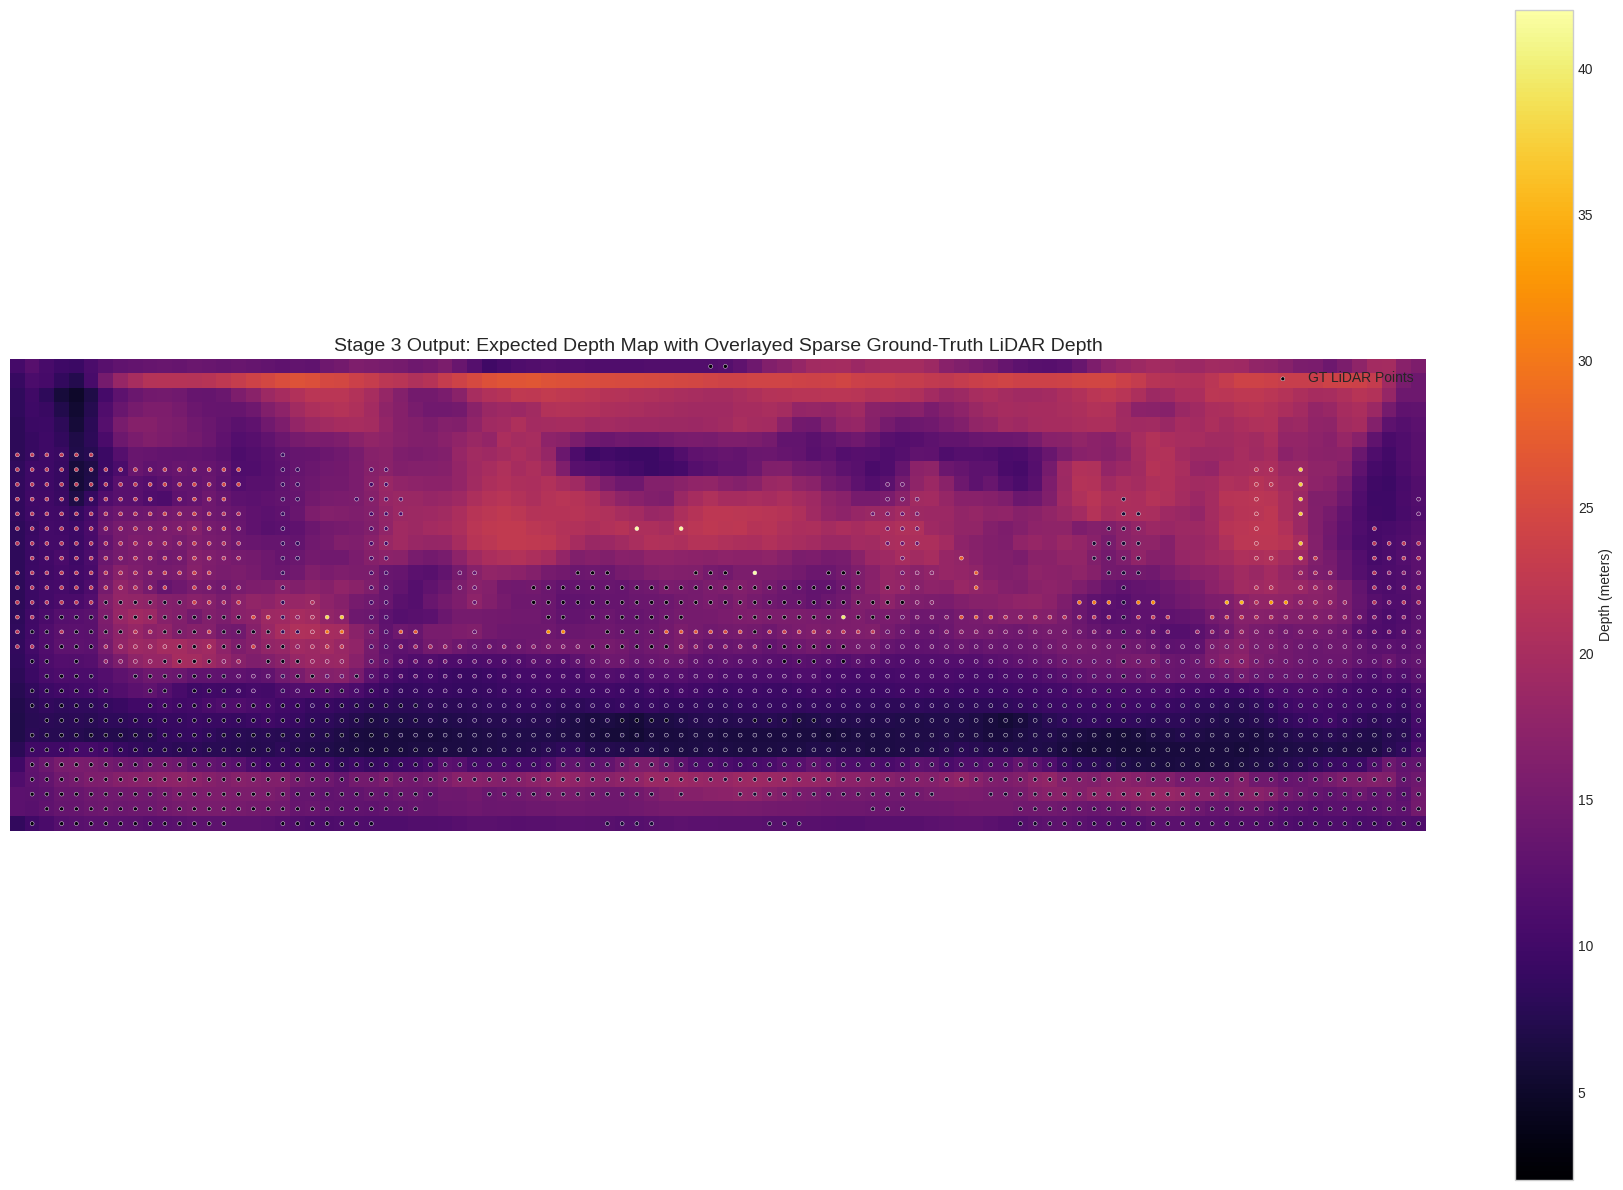

In [6]:
# Run lifting stage
with torch.no_grad():
    frustum_1, depth_probs_1 = model.lift(feat_1)
print(f"Perspective Features Input Shape: {feat_1.shape}")
print(f"Frustum Tensor Output Shape: {frustum_1.shape}")
print(f"Depth Probabilities Output Shape: {depth_probs_1.shape}")

# Calculate expected depth map for visualization: sum_d (probs_d * depth_d)
depth_bins = torch.linspace(2.0, 42.0, 40, device=device).view(40, 1, 1)
expected_depth_1 = torch.sum(depth_probs_1[0] * depth_bins, dim=0).detach().cpu().numpy()

# Retrieve ground truth depth targets from sparse LiDAR sweeps
gt_depth_1 = sample_1['depth_target'][0].numpy()
depth_mask_1 = sample_1['depth_mask'][0].numpy()

plt.figure(figsize=(18, 12))

# Predicted Depth overlayed with sparse LiDAR ground-truth depth
plt.imshow(expected_depth_1, cmap='inferno', vmin=2.0, vmax=42.0, aspect='equal')
y_indices, x_indices = np.where(depth_mask_1 > 0.5)
if len(x_indices) > 0:
    plt.scatter(x_indices, y_indices, c=gt_depth_1[y_indices, x_indices], cmap='inferno', 
                s=8, edgecolors='white', linewidths=0.3, label="GT LiDAR Points")
plt.title("Stage 3 Output: Expected Depth Map with Overlayed Sparse Ground-Truth LiDAR Depth", fontsize=14)
plt.colorbar(label="Depth (meters)")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()



---
## Stage 4: Voxel Pooling & Smoothing

Project frustum features into a 100×100 BEV grid and apply lateral smoothing to reduce projection artifacts.


Frustum Input Shape: torch.Size([1, 80, 40, 32, 96])
Raw BEV Features Output Shape: torch.Size([1, 80, 100, 100])
Smoothed BEV Features Output Shape: torch.Size([1, 80, 100, 100])


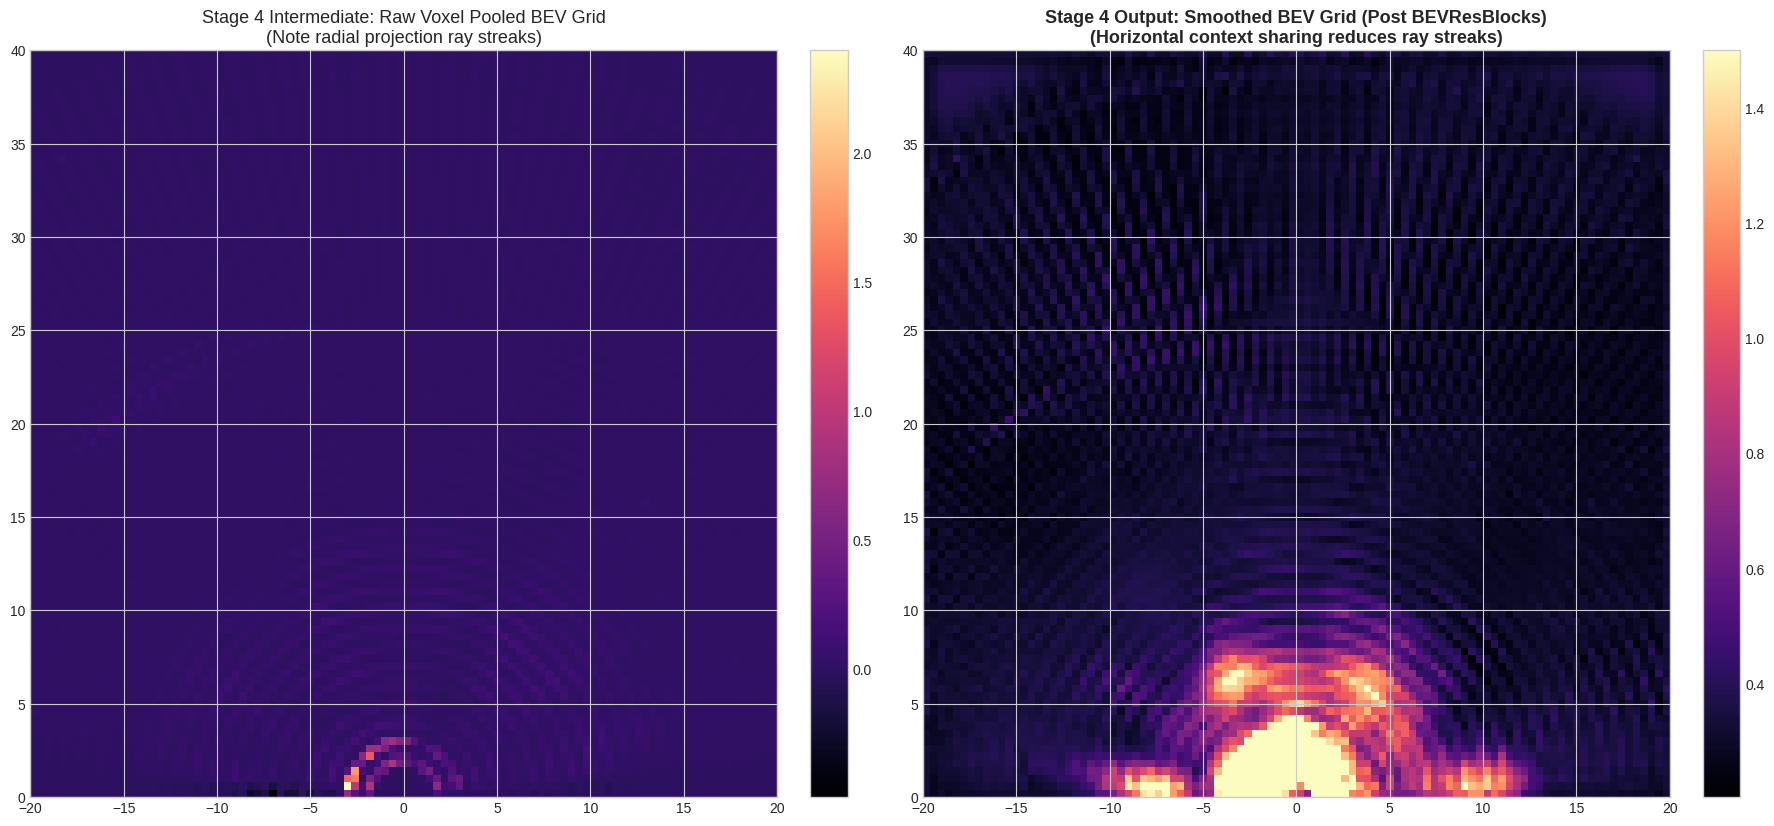

In [7]:
# Run voxel pooling and smoothing
with torch.no_grad():
    x_bev_raw_1 = model.pool(frustum_1)
    x_bev_smoothed_1 = model.bev_smooth(x_bev_raw_1)

print(f"Frustum Input Shape: {frustum_1.shape}")
print(f"Raw BEV Features Output Shape: {x_bev_raw_1.shape}")
print(f"Smoothed BEV Features Output Shape: {x_bev_smoothed_1.shape}")

# Visualize raw vs smoothed BEV features (average across channels)
raw_bev_np = torch.mean(x_bev_raw_1[0], dim=0).detach().cpu().numpy()
smooth_bev_np = torch.mean(x_bev_smoothed_1[0], dim=0).detach().cpu().numpy()

plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.imshow(raw_bev_np, cmap='magma', origin='upper', extent=[-20, 20, 0, 40])
plt.title("Stage 4 Intermediate: Raw Voxel Pooled BEV Grid\n(Note radial projection ray streaks)", fontsize=13)
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 2, 2)
plt.imshow(smooth_bev_np, cmap='magma', origin='upper', extent=[-20, 20, 0, 40], vmax=1.5)
plt.title("Stage 4 Output: Smoothed BEV Grid (Post BEVResBlocks)\n(Horizontal context sharing reduces ray streaks)", fontsize=13, fontweight='bold')
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()



---
## Stage 5: Warping & ConvGRU

Warp the previous BEV using ego motion and fuse it with the current BEV using a ConvGRU to get a fused state.


Temporal fusion execution complete.
Previous BEV shape: torch.Size([1, 80, 100, 100])
Warped previous BEV shape: torch.Size([1, 80, 100, 100])
Fused state shape: torch.Size([1, 80, 100, 100])


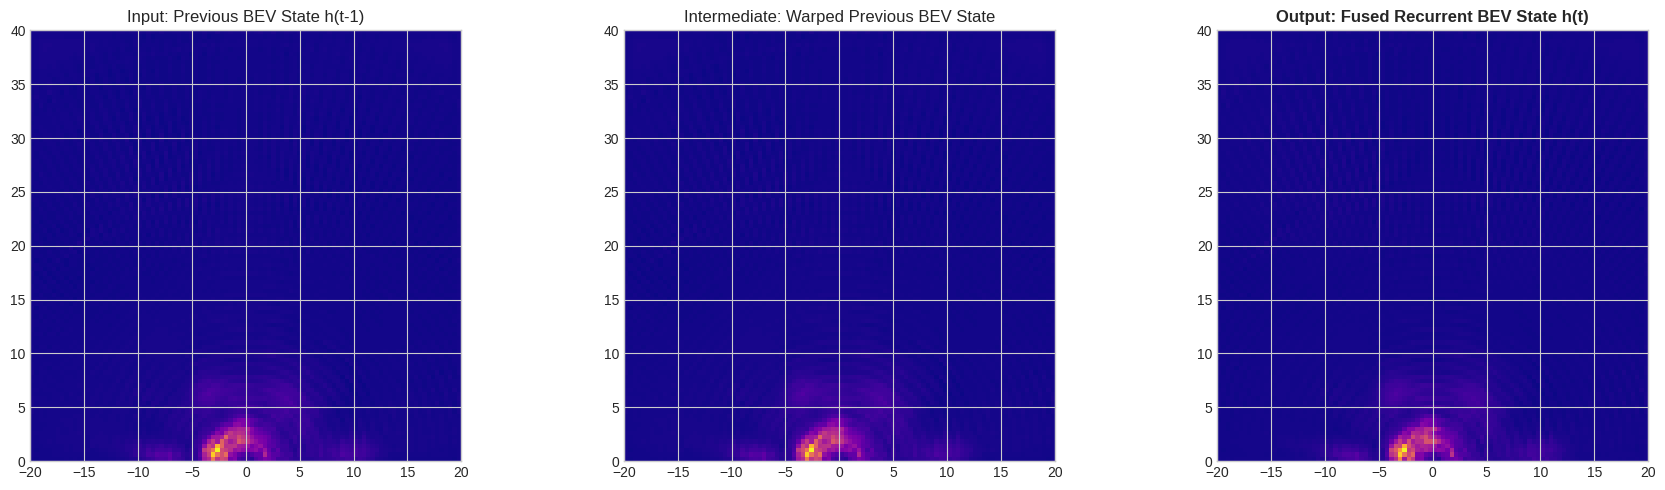

In [8]:
# Run previous sample to get its smoothed BEV representation
images_0 = sample_0['images'].unsqueeze(0).to(device)
intrinsics_0 = sample_0['intrinsics'].unsqueeze(0).to(device)
extrinsics_0 = sample_0['extrinsics'].unsqueeze(0).to(device)

with torch.no_grad():
    cyl_0, _, _, _ = model.projection(images_0, intrinsics_0, extrinsics_0)
    feat_0 = model.backbone(cyl_0)
    frustum_0, _ = model.lift(feat_0)
    x_bev_raw_0 = model.pool(frustum_0)
    x_bev_smoothed_0 = model.bev_smooth(x_bev_raw_0)

# Compute warp matrix and warp previous hidden state
from models.temporal_fusion import compute_warp_matrix
import kornia

with torch.no_grad():
    M_warp = compute_warp_matrix(ego_state_1, dt=0.5)
    # Warp previous BEV state
    h_prev_warped = kornia.geometry.transform.warp_affine(
        x_bev_smoothed_0, M_warp, dsize=(100, 100), mode='bilinear', padding_mode='zeros'
    )
    # Recurrent update
    h_next_1 = model.temporal_fusion(x_bev_smoothed_1, x_bev_smoothed_0, ego_state_1)

print("Temporal fusion execution complete.")
print(f"Previous BEV shape: {x_bev_smoothed_0.shape}")
print(f"Warped previous BEV shape: {h_prev_warped.shape}")
print(f"Fused state shape: {h_next_1.shape}")

# Visualize the warping sequence
prev_np = torch.mean(x_bev_smoothed_0[0], dim=0).detach().cpu().numpy()
warped_np = torch.mean(h_prev_warped[0], dim=0).detach().cpu().numpy()
fused_np = torch.mean(h_next_1[0], dim=0).detach().cpu().numpy()

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(prev_np, cmap='plasma', origin='upper', extent=[-20, 20, 0, 40])
plt.title("Input: Previous BEV State h(t-1)", fontsize=12)

plt.subplot(1, 3, 2)
plt.imshow(warped_np, cmap='plasma', origin='upper', extent=[-20, 20, 0, 40])
plt.title("Intermediate: Warped Previous BEV State", fontsize=12)

plt.subplot(1, 3, 3)
plt.imshow(fused_np, cmap='plasma', origin='upper', extent=[-20, 20, 0, 40])
plt.title("Output: Fused Recurrent BEV State h(t)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



---
## Stage 6 & 7: Planning Head

Stage 6: score K=16 anchors using cross-attention. Stage 7: regress offsets for the chosen anchor to produce refined waypoints.

Visuals: probability bar plot and candidate trajectories overlayed on the drivable map.


Chosen trajectory index: 10 with probability 0.0966


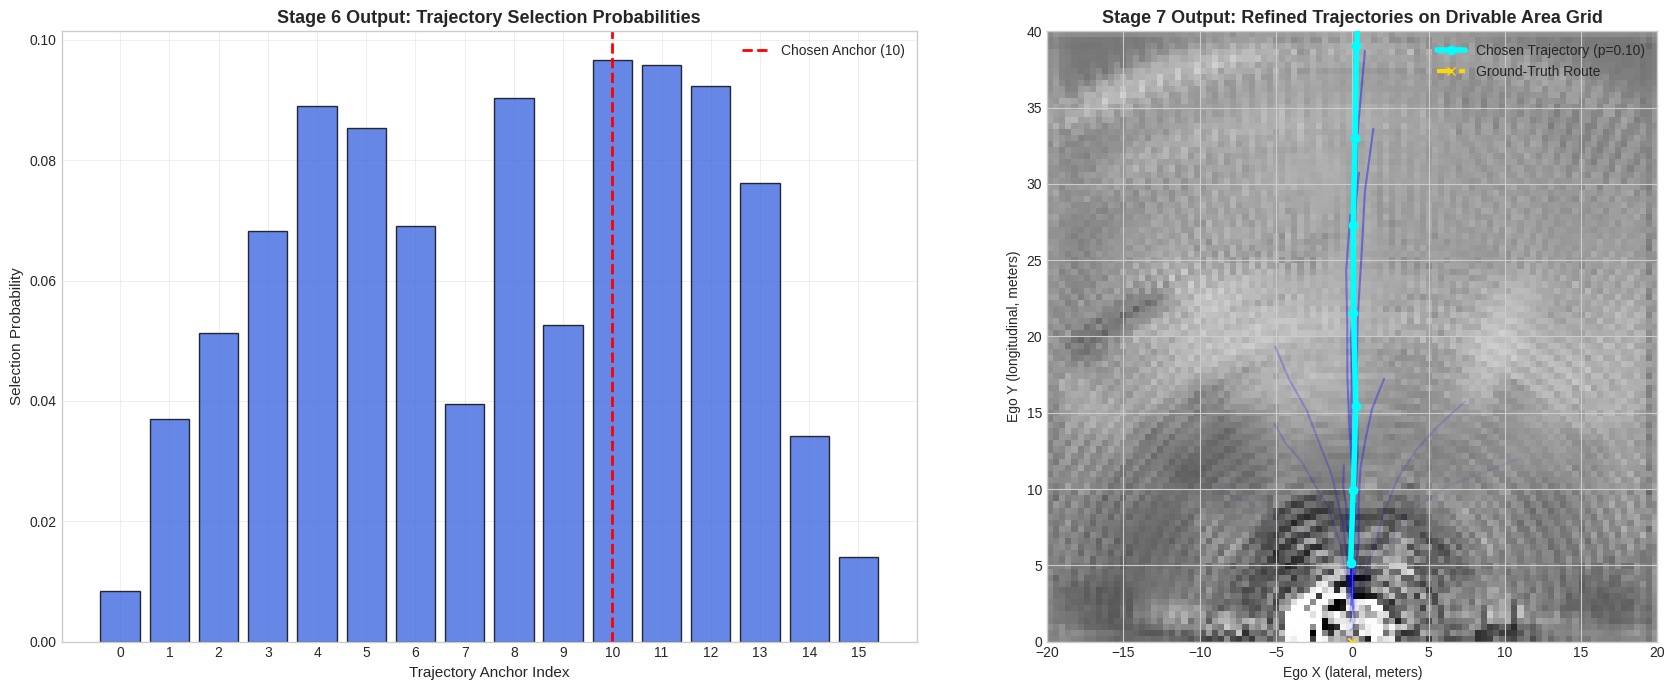

In [9]:
# Run planning head
with torch.no_grad():
    logits_1, trajectories_1, drivable_preds_1, occupancy_preds_1 = model.planning_head(h_next_1)

# Extract choice parameters
probs_1 = torch.softmax(logits_1, dim=-1)[0].detach().cpu().numpy()
trajectories_np_1 = trajectories_1[0].detach().cpu().numpy()
best_idx_1 = int(torch.argmax(logits_1, dim=-1)[0].item())
gt_traj_1 = sample_1['future_traj'].numpy()

print(f"Chosen trajectory index: {best_idx_1} with probability {probs_1[best_idx_1]:.4f}")

plt.figure(figsize=(18, 7))

# Subplot 1: Probability Distribution
plt.subplot(1, 2, 1)
plt.bar(range(16), probs_1, color='royalblue', edgecolor='k', alpha=0.8)
plt.axvline(best_idx_1, color='red', linestyle='--', linewidth=2, label=f'Chosen Anchor ({best_idx_1})')
plt.xticks(range(16))
plt.xlabel("Trajectory Anchor Index", fontsize=11)
plt.ylabel("Selection Probability", fontsize=11)
plt.title("Stage 6 Output: Trajectory Selection Probabilities", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Trajectories visual plot
drivable_prob_1 = torch.sigmoid(drivable_preds_1[0, 0]).detach().cpu().numpy()
plt.subplot(1, 2, 2)
plt.imshow(drivable_prob_1, cmap='gray', origin='upper', extent=[-20, 20, 0, 40])

# Plot all candidate trajectories, fading out unselected ones
for k in range(16):
    grid_x = trajectories_np_1[k, :, 0]
    grid_y = trajectories_np_1[k, :, 1]
    
    alpha_val = float(max(0.1, probs_1[k] / (probs_1.max() + 1e-8)))
    if k == best_idx_1:
        plt.plot(grid_x, grid_y, color='cyan', linewidth=4, marker='o', label=f'Chosen Trajectory (p={probs_1[k]:.2f})', zorder=5)
    else:
        plt.plot(grid_x, grid_y, color='blue', alpha=alpha_val * 0.4, linewidth=1.5, zorder=2)

# Plot ground-truth trajectory
gt_grid_x = gt_traj_1[:, 0]
gt_grid_y = gt_traj_1[:, 1]
plt.plot(gt_grid_x, gt_grid_y, color='gold', linewidth=3, linestyle='--', marker='x', label='Ground-Truth Route', zorder=6)

plt.title("Stage 7 Output: Refined Trajectories on Drivable Area Grid", fontsize=13, fontweight='bold')
plt.legend()
plt.xlim(-20, 20)
plt.ylim(0, 40)
plt.xlabel("Ego X (lateral, meters)")
plt.ylabel("Ego Y (longitudinal, meters)")
plt.tight_layout()
plt.show()



---
## Stage 8: Auxiliary Decoders & Safety Metrics

Predict drivable area and occupancy grids. Compute collision rate and drivable-compliance for the chosen trajectory and show side-by-side maps.


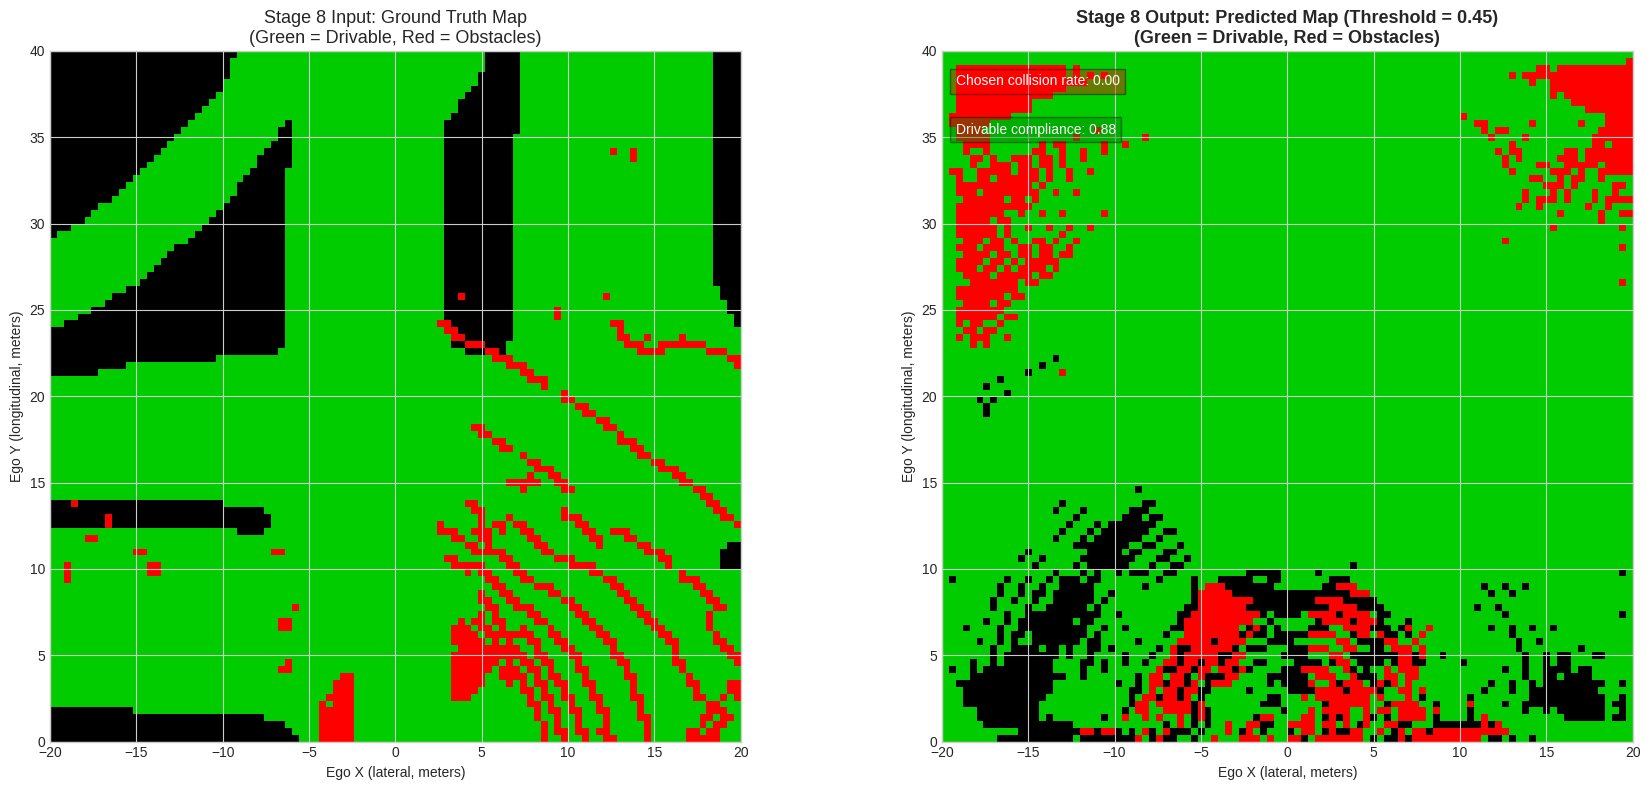

In [10]:
# Get prediction maps
drivable_pred_1 = torch.sigmoid(drivable_preds_1[0, 0]).detach().cpu().numpy()
occupancy_pred_1 = torch.sigmoid(occupancy_preds_1[0, 0]).detach().cpu().numpy()

# Get ground-truth maps
gt_drivable_1 = sample_1['drivable_target'][0].numpy()
gt_occupancy_1 = sample_1['occupancy_target'][0].numpy()

# Compile color maps for side-by-side presentation
# Green = Drivable area, Red = Occupancy/Obstacles
gt_map_1 = np.zeros((100, 100, 3))
gt_map_1[gt_drivable_1 > 0.5] = [0.0, 0.8, 0.0]
gt_map_1[gt_occupancy_1 > 0.5] = [1.0, 0.0, 0.0]

pred_map_1 = np.zeros((100, 100, 3))
pred_map_1[drivable_pred_1 > 0.45] = [0.0, 0.8, 0.0]
pred_map_1[occupancy_pred_1 > 0.45] = [1.0, 0.0, 0.0]

# Compute chosen trajectory safety metrics
chosen_traj = trajectories_np_1[best_idx_1]
# Map trajectory waypoints to grid indices
x_range = (-20.0, 20.0)
y_range = (0.0, 40.0)
W_bev = occupancy_pred_1.shape[1]
H_bev = occupancy_pred_1.shape[0]
idx_x = ((chosen_traj[:,0] - x_range[0]) / (x_range[1] - x_range[0]) * W_bev).astype(int)
idx_y = ((y_range[1] - chosen_traj[:,1]) / (y_range[1] - y_range[0]) * H_bev).astype(int)
# Clip indices
idx_x = np.clip(idx_x, 0, W_bev - 1)
idx_y = np.clip(idx_y, 0, H_bev - 1)
# Collision check
collisions = occupancy_pred_1[idx_y, idx_x] > 0.5
collision_rate_chosen = collisions.mean()
# Drivable compliance
drivable_flags = drivable_pred_1[idx_y, idx_x] > 0.45
drivable_compliance = drivable_flags.mean()

plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.imshow(gt_map_1, origin='upper', extent=[-20, 20, 0, 40])
plt.title("Stage 8 Input: Ground Truth Map\n(Green = Drivable, Red = Obstacles)", fontsize=13)
plt.axis('on')
plt.xlabel("Ego X (lateral, meters)")
plt.ylabel("Ego Y (longitudinal, meters)")

plt.subplot(1, 2, 2)
plt.imshow(pred_map_1, origin='upper', extent=[-20, 20, 0, 40])
plt.title("Stage 8 Output: Predicted Map (Threshold = 0.45)\n(Green = Drivable, Red = Obstacles)", fontsize=13, fontweight='bold')
plt.axis('on')
plt.xlabel("Ego X (lateral, meters)")
plt.ylabel("Ego Y (longitudinal, meters)")
# Annotate chosen trajectory safety metrics
plt.text(0.02, 0.95, f'Chosen collision rate: {collision_rate_chosen:.2f}', transform=plt.gca().transAxes, color='white', fontsize=10, bbox=dict(facecolor='red', alpha=0.4))
plt.text(0.02, 0.88, f'Drivable compliance: {drivable_compliance:.2f}', transform=plt.gca().transAxes, color='white', fontsize=10, bbox=dict(facecolor='green', alpha=0.4))
plt.tight_layout()
plt.show()

